# SCF of Simple molecule

### Background of Self Consistent Field Cycle

In DFT, solving Kohn Sham equation must be consistenly, Hamiltonian depend on the electron density, and from the elctron density a new hamiltonian matrix turn out.This create a iterative loop.

Initially, guess an electron density (or Density matrix )and compute a hamiltonian matrix. Then solving the Kohn Sham equation gives a new density matrix, this loop can continue till to reach convergence.

A typical way to accelerate the SCF cycle is to adopt a mixing strategy. This refers essentially to a type of extrapolation, in which we aim for better predictions of the Hamiltonian (or Density Matrix) for the next SCF step. Whether a calculation reaches self-consistency in a moderate number of steps depends strongly on the mixing strategy used. Therefore, choosing the appropriate mixing options for a given system can potentially save many self-consistency steps in production runs. Without proper control, the iterations may diverge, oscillate, or converge very slowly.

In this tutorial we will see a brief summary of the options related to self-consistency, and will practice with them. We strongly suggest to have a look at the manual in case more advanced options are required.

In [50]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/scf-convergence/01-CH4/practice1/density


In [11]:
!mkdir -p density

In [12]:
ls

ch4-mix.fdf  C.psml  density/  H.psml


In [13]:
!cp C.psml H.psml ch4-mix.fdf density/

In [15]:
%cd density/

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/scf-convergence/01-CH4/practice1/density


/home/l-rishiraj/miniconda3/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [16]:
ls

ch4-mix.fdf  C.psml  H.psml


In [17]:
!cat ch4-mix.fdf

#General system specifications
SystemName          CH4 molecule -- test mixing options
SystemLabel         ch4-mix
NumberOfAtoms       5
NumberOfSpecies     2

%block ChemicalSpeciesLabel
 1  6 C   # Species index, atomic number, species label
 2  1 H   # Species index, atomic number, species label
%endblock ChemicalSpeciesLabel

#Unit cell for the calculation
LatticeConstant 15 Ang
%block LatticeVectors 
  1.000 0.000 0.000
  0.000 1.000 0.000
  0.000 0.000 1.000
%endblock LatticeVectors

#Atomic coordinates
AtomicCoordinatesFormat  Ang

%block AtomicCoordinatesAndAtomicSpecies
  0.000      0.000      0.000   1
  1.219     -0.284     -0.377   2 
 -0.284      1.219     -0.377   2 
 -0.140     -0.140      1.219   2 
 -0.833     -0.833     -0.503   2 
%endblock AtomicCoordinatesAndAtomicSpecies

# Basis set definition
PAO.EnergyShift 250 meV
PAO.SplitNorm   0.15
PAO.BasisSize   DZP

#Real space grid 
MeshCutoff 125.0 Ry

# Convergence of SCF 
Max.SCF.Iterations 100

SCF.mix density
SCF.m

In [51]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/scf-convergence/01-CH4/practice1/density


In [52]:
mixer_method = ["linear", "Pulay", "Broyden"]
mixer_weight = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

for METHOD in mixer_method:
    for W in mixer_weight:

        folder = f"SCF_{METHOD}_W{W}"

        print("="*35)
        print(f"Running METHOD = {METHOD}   WEIGHT = {W}")
        print("="*35)

        # create folder
        !mkdir -p {folder}

        # copy files
        !cp ch4-mix.fdf C.psml H.psml {folder}/

        # modify method + weight
        !sed -i "s/^SCF.mixer.method.*/SCF.mixer.method {METHOD}/" {folder}/ch4-mix.fdf
        !sed -i "s/^SCF.mixer.weight.*/SCF.mixer.weight {W}/" {folder}/ch4-mix.fdf

        # run siesta
        !cd {folder} && siesta < ch4-mix.fdf > ch4-mix.out

        


Running METHOD = linear   WEIGHT = 0.1
Job completed
Running METHOD = linear   WEIGHT = 0.2
Job completed
Running METHOD = linear   WEIGHT = 0.3
Job completed
Running METHOD = linear   WEIGHT = 0.4
Job completed
Running METHOD = linear   WEIGHT = 0.5
Job completed
Running METHOD = linear   WEIGHT = 0.6
Job completed
Running METHOD = linear   WEIGHT = 0.7
SCF_NOT_CONV: SCF did not converge in maximum number of steps (required).
Geom step, scf iteration, dDmax, dHmax:    0   100      0.388045     0.586422
ABNORMAL_TERMINATION
Stopping Program from Node:    0

Program received signal SIGABRT: Process abort signal.

Backtrace for this error:
#0  0x77872d04532f in ???
	at ./signal/../sysdeps/unix/sysv/linux/x86_64/libc_sigaction.c:0
#1  0x77872d09eb2c in __pthread_kill_implementation
	at ./nptl/pthread_kill.c:44
#2  0x77872d09eb2c in __pthread_kill_internal
	at ./nptl/pthread_kill.c:78
#3  0x77872d09eb2c in __GI___pthread_kill
	at ./nptl/pthread_kill.c:89
#4  0x77872d04527d in __GI_raise
	a

In [54]:
!for method in linear Pulay Broyden; do \
  echo "==============================="; \
  echo "METHOD: $method"; \
  echo "WEIGHT   SCF_ITER"; \
  echo "------------------"; \
  for f in SCF_${method}_W*; do \
    w=$(echo $f | sed 's/.*_W//'); \
    it=$(grep "^diagon" $f/ch4-mix.out | tail -1 | awk '{print $2}'); \
    printf "%-6s   %s\n" "$w" "$it"; \
  done | sort -k1,1n; \
  echo ""; \
done


METHOD: linear
WEIGHT   SCF_ITER
------------------
0.1      95
0.2      45
0.3      29
0.4      21
0.5      16
0.6      27
0.7      100
0.8      100
0.9      100
1.0      100

METHOD: Pulay
WEIGHT   SCF_ITER
------------------
0.1      22
0.2      17
0.3      16
0.4      10
0.5      11
0.6      8
0.7      10
0.8      10
0.9      10
1.0      15

METHOD: Broyden
WEIGHT   SCF_ITER
------------------
0.1      46
0.2      25
0.3      13
0.4      13
0.5      11
0.6      9
0.7      100
0.8      100
0.9      100
1.0      100



In [55]:
!for method in linear Pulay Broyden; do \
  echo "==============================="; \
  echo "METHOD: $method"; \
  echo "WEIGHT   SCF_ITER   STATUS"; \
  echo "-----------------------------"; \
  for f in SCF_${method}_W*; do \
    w=$(echo $f | sed 's/.*_W//'); \
    it=$(grep "^diagon" $f/ch4-mix.out | tail -1 | awk '{print $2}'); \
    status="CONVERGED"; \
    if grep -q "SCF_NOT_CONV" $f/ch4-mix.out; then status="NOT_CONV"; fi; \
    printf "%-6s   %-7s   %s\n" "$w" "$it" "$status"; \
  done | sort -k1,1n; \
  echo ""; \
done


METHOD: linear
WEIGHT   SCF_ITER   STATUS
-----------------------------
0.1      95        CONVERGED
0.2      45        CONVERGED
0.3      29        CONVERGED
0.4      21        CONVERGED
0.5      16        CONVERGED
0.6      27        CONVERGED
0.7      100       NOT_CONV
0.8      100       NOT_CONV
0.9      100       NOT_CONV
1.0      100       NOT_CONV

METHOD: Pulay
WEIGHT   SCF_ITER   STATUS
-----------------------------
0.1      22        CONVERGED
0.2      17        CONVERGED
0.3      16        CONVERGED
0.4      10        CONVERGED
0.5      11        CONVERGED
0.6      8         CONVERGED
0.7      10        CONVERGED
0.8      10        CONVERGED
0.9      10        CONVERGED
1.0      15        CONVERGED

METHOD: Broyden
WEIGHT   SCF_ITER   STATUS
-----------------------------
0.1      46        CONVERGED
0.2      25        CONVERGED
0.3      13        CONVERGED
0.4      13        CONVERGED
0.5      11        CONVERGED
0.6      9         CONVERGED
0.7      100       NOT_CONV
0.8 

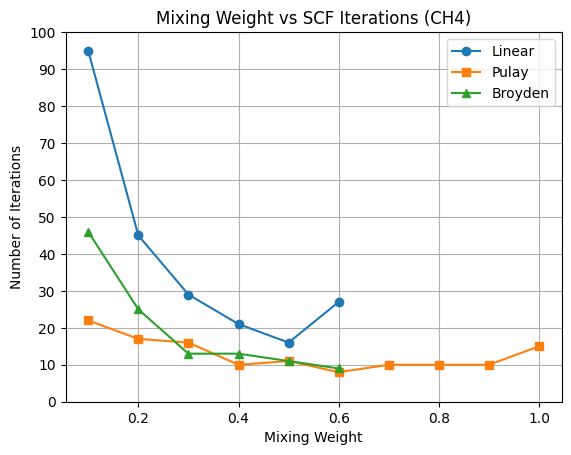

In [59]:
import matplotlib.pyplot as plt

weights_6  = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
weights_10 = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

Linear  = [95, 45, 29, 21, 16, 27]
Broyden = [46, 25, 13, 13, 11, 9]
Pulay   = [22, 17, 16, 10, 11, 8, 10, 10, 10, 15]

plt.title("Mixing Weight vs SCF Iterations (CH4)")

plt.plot(weights_6, Linear, marker='o', linestyle='-', label="Linear")
plt.plot(weights_10, Pulay, marker='s', linestyle='-', label="Pulay")
plt.plot(weights_6, Broyden, marker='^', linestyle='-', label="Broyden")

plt.xlabel("Mixing Weight")
plt.ylabel("Number of Iterations")
plt.yticks(range(0, 101, 10))

plt.legend()
plt.grid(True)
plt.show()


In [60]:
%cd ..

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/scf-convergence/01-CH4/practice1


/home/l-rishiraj/miniconda3/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [61]:
!mkdir -p Hamiltonian

In [62]:
ls

ch4-mix.fdf  C.psml  density/  Hamiltonian/  H.psml


In [63]:
!cp ch4-mix.fdf  C.psml H.psml Hamiltonian/

In [64]:
%cd Hamiltonian

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/scf-convergence/01-CH4/practice1/Hamiltonian


In [65]:
ls

ch4-mix.fdf  C.psml  H.psml


In [66]:
mixer_method = ["linear", "Pulay", "Broyden"]
mixer_weight = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

for METHOD in mixer_method:
    for W in mixer_weight:

        folder = f"SCF_{METHOD}_W{W}"

        print("="*35)
        print(f"Running METHOD = {METHOD}   WEIGHT = {W}")
        print("="*35)

        # create folder
        !mkdir -p {folder}

        # copy files
        !cp ch4-mix.fdf C.psml H.psml {folder}/

        # modify method + weight
        !sed -i "s/^SCF.mixer.method.*/SCF.mixer.method {METHOD}/" {folder}/ch4-mix.fdf
        !sed -i "s/^SCF.mixer.weight.*/SCF.mixer.weight {W}/" {folder}/ch4-mix.fdf

        # run siesta
        !cd {folder} && siesta < ch4-mix.fdf > ch4-mix.out

        


Running METHOD = linear   WEIGHT = 0.1
Job completed
Running METHOD = linear   WEIGHT = 0.2
Job completed
Running METHOD = linear   WEIGHT = 0.3
Job completed
Running METHOD = linear   WEIGHT = 0.4
Job completed
Running METHOD = linear   WEIGHT = 0.5
Job completed
Running METHOD = linear   WEIGHT = 0.6
Job completed
Running METHOD = linear   WEIGHT = 0.7
SCF_NOT_CONV: SCF did not converge in maximum number of steps (required).
Geom step, scf iteration, dDmax, dHmax:    0    70      0.424728     0.705793
ABNORMAL_TERMINATION
Stopping Program from Node:    0

Program received signal SIGABRT: Process abort signal.

Backtrace for this error:
#0  0x7592f804532f in ???
	at ./signal/../sysdeps/unix/sysv/linux/x86_64/libc_sigaction.c:0
#1  0x7592f809eb2c in __pthread_kill_implementation
	at ./nptl/pthread_kill.c:44
#2  0x7592f809eb2c in __pthread_kill_internal
	at ./nptl/pthread_kill.c:78
#3  0x7592f809eb2c in __GI___pthread_kill
	at ./nptl/pthread_kill.c:89
#4  0x7592f804527d in __GI_raise
	a

In [67]:
!for method in linear Pulay Broyden; do \
  echo "==============================="; \
  echo "METHOD: $method"; \
  echo "WEIGHT   SCF_ITER   STATUS"; \
  echo "-----------------------------"; \
  for f in SCF_${method}_W*; do \
    w=$(echo $f | sed 's/.*_W//'); \
    it=$(grep "^diagon" $f/ch4-mix.out | tail -1 | awk '{print $2}'); \
    status="CONVERGED"; \
    if grep -q "SCF_NOT_CONV" $f/ch4-mix.out; then status="NOT_CONV"; fi; \
    printf "%-6s   %-7s   %s\n" "$w" "$it" "$status"; \
  done | sort -k1,1n; \
  echo ""; \
done


METHOD: linear
WEIGHT   SCF_ITER   STATUS
-----------------------------
0.1      61        CONVERGED
0.2      29        CONVERGED
0.3      19        CONVERGED
0.4      13        CONVERGED
0.5      12        CONVERGED
0.6      28        CONVERGED
0.7      70        NOT_CONV
0.8      70        NOT_CONV
0.9      70        NOT_CONV
1.0      70        NOT_CONV

METHOD: Pulay
WEIGHT   SCF_ITER   STATUS
-----------------------------
0.1      13        CONVERGED
0.2      10        CONVERGED
0.3      9         CONVERGED
0.4      8         CONVERGED
0.5      7         CONVERGED
0.6      7         CONVERGED
0.7      7         CONVERGED
0.8      7         CONVERGED
0.9      11        CONVERGED
1.0      12        CONVERGED

METHOD: Broyden
WEIGHT   SCF_ITER   STATUS
-----------------------------
0.1      16        CONVERGED
0.2      9         CONVERGED
0.3      9         CONVERGED
0.4      8         CONVERGED
0.5      7         CONVERGED
0.6      7         CONVERGED
0.7      7         CONVERGED
0.8

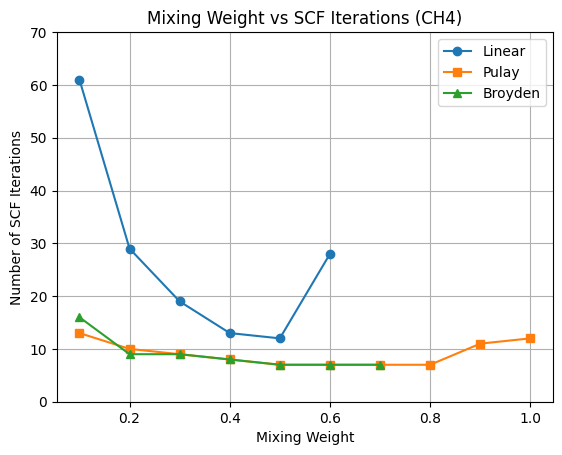

In [71]:
import matplotlib.pyplot as plt

weights_6 = [0.1,0.2,0.3,0.4,0.5,0.6]
weights_7 = [0.1,0.2,0.3,0.4,0.5,0.6,0.7]
weights_10 = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

Linear  = [61, 29, 19, 13, 12, 28]

Pulay   = [13, 10,  9,  8,  7,  7,  7,  7, 11, 12]
Broyden = [16,  9,  9,  8,  7,  7,  7]

plt.title("Mixing Weight vs SCF Iterations (CH4)")
plt.plot(weights_6, Linear,  marker='o', linestyle='-', label="Linear")
plt.plot(weights_10, Pulay,   marker='s', linestyle='-', label="Pulay")
plt.plot(weights_7, Broyden, marker='^', linestyle='-', label="Broyden")

plt.xlabel("Mixing Weight")
plt.ylabel("Number of SCF Iterations")

plt.ylim(0, 70)
plt.yticks(range(0, 71, 10))

plt.legend()
plt.grid(True)
plt.show()


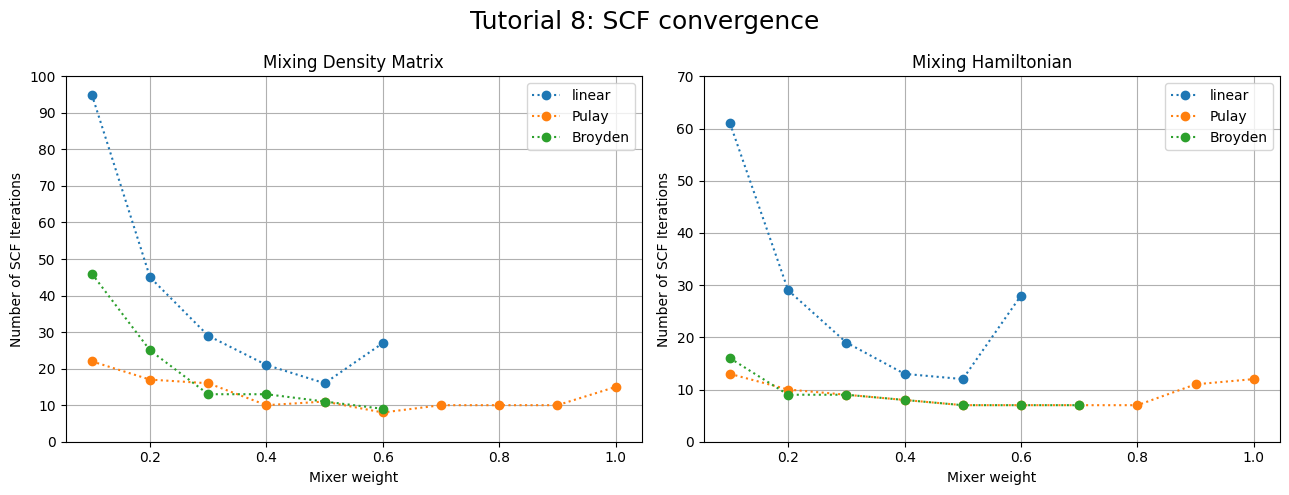

In [76]:
import matplotlib.pyplot as plt

weights_6 = [0.1,0.2,0.3,0.4,0.5,0.6]
weights_7 = [0.1,0.2,0.3,0.4,0.5,0.6,0.7]
weights_10 = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
# Density matrix mixing
Linear_D  = [95, 45, 29, 21, 16, 27]
Broyden_D = [46, 25, 13, 13, 11, 9]
Pulay_D   = [22, 17, 16, 10, 11, 8, 10, 10, 10, 15]

# Hamiltonian mixing
Linear_H  = [61, 29, 19, 13, 12, 28]
Pulay_H   = [13, 10,  9,  8,  7,  7,  7,  7, 11, 12]
Broyden_H = [16,  9,  9,  8,  7,  7,  7]

plt.figure(figsize=(13,5))
#plot the mixing density 
# ---------------- Plot 1 ----------------
plt.subplot(1,2,1)
plt.plot(weights_6, Linear_D,  marker='o', linestyle=':', label="linear")
plt.plot(weights_10, Pulay_D,   marker='o', linestyle=':', label="Pulay")
plt.plot(weights_6, Broyden_D, marker='o', linestyle=':', label="Broyden")

plt.title("Mixing Density Matrix")
plt.xlabel("Mixer weight")
plt.ylabel("Number of SCF Iterations")
plt.ylim(0, 100)
plt.yticks(range(0, 101, 10))
plt.grid(True)
plt.legend()

# ---------------- Plot 2 ----------------
plt.subplot(1,2,2)
plt.plot(weights_6, Linear_H,  marker='o', linestyle=':', label="linear")
plt.plot(weights_10, Pulay_H,   marker='o', linestyle=':', label="Pulay")
plt.plot(weights_7, Broyden_H, marker='o', linestyle=':', label="Broyden")

plt.title("Mixing Hamiltonian")
plt.xlabel("Mixer weight")
plt.ylabel("Number of SCF Iterations")
plt.ylim(0, 70)
plt.yticks(range(0, 71, 10))
plt.grid(True)
plt.legend()

plt.suptitle("Tutorial 8: SCF convergence", fontsize=18)
plt.tight_layout()
plt.show()
